# 🏆 Project #17: Automated Resume Screening Engine
**Architect:** Kemal Demirbaş 🏰🚀 | **Project Series:** 17 of 21

## 🎯 Vision: HR Pipeline Optimization
In the modern corporate landscape, HR departments receive thousands of resumes daily. This project builds an **Automated Resume Screening Engine** that reads, cleanses, and classifies CVs into 25 specific job categories (Data Science, HR, Web Designing, etc.) in milliseconds. By eliminating manual screening, we optimize the hiring pipeline using **Natural Language Processing (NLP)** and **Machine Learning**.

---

## 🏗️ The 10-Step Architectural Blueprint
This engine is strictly built upon the **Senior Architect's 10-Step Recipe**, utilizing advanced text processing and a diversified modeling strategy:

1.  **Cloud Data Integration:** Fetching the robust 962-row dataset directly via active external repositories to ensure architectural portability and reproducibility.
2.  **Noise Extraction (Emails & Emojis):** Utilizing the `neattext` library to systematically strip out unprofessional artifacts like personal emails and emojis from the raw text.
3.  **Case Normalization:** Standardizing all resume text to lowercase to ensure character uniformity across the pipeline.
4.  **Punctuation & Symbol Stripping:** Deep cleansing of special characters, URLs, and non-alphabetic noise using `nfx.remove_special_characters`.
5.  **Artifact Cleansing:** Eliminating hidden BOM characters, carriage returns, and structural artifacts from the data streams.
6.  **Stopwords Filtration:** Automatically tokenizing sentences and dropping high-frequency, low-information words via `nfx.clean_text`.
7.  **Label Encoding:** Translating 25 distinct categorical job titles into machine-readable numeric IDs.
8.  **Vectorization (TF-IDF):** Transforming the cleansed text into a 4000-feature mathematical matrix using **Term Frequency-Inverse Document Frequency**, acting as the ultimate text scaler.
9.  **Stratified Partitioning:** Splitting the matrix into `X_train` and `X_test` using strict stratification to prevent minority class collapse across the 25 professions.
10. **Diversified Modeling & The "Bottleneck Fix":** Executing three distinct architectural models:
    * **Classic ML:** Multinomial Naive Bayes.
    * **Ensemble Power:** Random Forest Classifier (Achieving **99.48%** Accuracy).
    * **Deep Learning (Sequential):** Implementing a customized neural network where the standard hidden layer bottleneck was successfully expanded to 64 neurons, allowing perfect assimilation of multi-class resume data (Achieving **98.96%** Accuracy).



In [37]:
# ==============================================================================
# --- 1. DATA ACQUISITION & LIBRARIES ---
# ==============================================================================
#!pip install neattext

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import neattext as nfx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from wordcloud import WordCloud
import warnings

warnings.filterwarnings("ignore")

In [38]:
# Loading the public Resume Dataset directly from an active GitHub repository
url = "https://raw.githubusercontent.com/611noorsaeed/Resume-Screening-App/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url, encoding='utf-8')

In [39]:
# Cleaning hidden BOM characters and dropping missing rows just in case
df.columns = df.columns.str.replace('\ufeff', '').str.strip()
df = df.dropna(subset=['Category', 'Resume'])

In [40]:
# Standardizing column names for the NLP pipeline
df = df.rename(columns={'Category': 'label', 'Resume': 'text'})
df = df[['label', 'text']]

In [41]:
from sklearn.preprocessing import LabelEncoder
# Algorithms use Label Encoder to better understand 25 different string professions.
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['label'])

In [42]:
# ==============================================================================
# --- NEATTEXT NLP PREPROCESSING PIPELINE ---
# ==============================================================================

# Extra steps: Extracting and removing emails and emojis
df['text'] = df['text'].apply(nfx.remove_emails)
df['text'] = df['text'].apply(nfx.remove_emojis)

In [43]:
# --- STEPS 2, 3, 4, 5: LOWERCASE, PUNCTUATION, NUMBERS, AND NEWLINES ---
df['text'] = df['text'].apply(nfx.normalize)
df['text'] = df['text'].apply(nfx.remove_special_characters)

In [44]:
# --- STEPS 6, 7, 8: STOPWORDS, TOKENIZATION, AND STEMMING LOGIC ---
df['text'] = df['text'].apply(nfx.clean_text)

In [45]:
# ==============================================================================
# --- WORDCLOUD PREPARATION ---
# ==============================================================================
# Joining all processed text to create a TextFrame
s = ' '.join(df['text'])
docx = nfx.TextFrame(s)

In [46]:
# ==============================================================================
# --- STEPS 9 & 10: VECTORIZATION AND TF-IDF (Ordering Rule) ---
# ==============================================================================
# Scaling the text into mathematical vectors using TF-IDF prior to modeling
tfidf_vectorizer = TfidfVectorizer(max_features=4000)
X = tfidf_vectorizer.fit_transform(df['text']).toarray()

In [47]:
# Setting up the target labels
y_classic = df['label'] # For Naive Bayes and Random Forest
y_dl = pd.get_dummies(df['label']).values # For Deep Learning (One-Hot Encoding)

# Data Partitioning
X_train, X_test, y_train, y_test = train_test_split(X, y_classic, test_size=0.2, random_state=42, stratify=y_classic)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X, y_dl, test_size=0.2, random_state=42, stratify=y_classic)

In [48]:
# ==============================================================================
# --- DIVERSIFYING MODELS ---
# ==============================================================================

# MODEL 1: CLASSIC ML (Naive Bayes)
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb_model.predict(X_test))

In [49]:
# MODEL 2: RANDOM FOREST
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

In [50]:
# MODEL 3: DEEP LEARNING
dl_model = Sequential()
dl_model.add(Dense(80, activation='relu', input_dim=X_train_dl.shape[1]))
dl_model.add(Dense(120, activation='relu'))
dl_model.add(Dense(100, activation='relu'))
dl_model.add(Dense(80, activation='relu'))
dl_model.add(Dense(30, activation='relu'))
dl_model.add(Dense(64, activation='relu'))


#  CVs have multiple categories, the final layer is Softmax.
dl_model.add(Dense(y_dl.shape[1], activation='softmax'))

dl_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
dl_model.fit(X_train_dl, y_train_dl, epochs=5, batch_size=32, verbose=1)
dl_acc = dl_model.evaluate(X_test_dl, y_test_dl, verbose=0)[1]

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0871 - loss: 3.1749
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2705 - loss: 2.4974
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5319 - loss: 1.3638
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8960 - loss: 0.4337
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9831 - loss: 0.1029


In [51]:
# ==============================================================================
# --- VISUALIZATION AND PERFORMANCE AUDIT ---
# ==============================================================================
print(f"\n📊 --- RESUME SCREENING PERFORMANCE REPORT --- 📊")
print(f"✅ Naive Bayes Accuracy: {nb_acc*100:.2f}%")
print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")
print(f"✅ Deep Learning Accuracy: {dl_acc*100:.2f}%")


📊 --- RESUME SCREENING PERFORMANCE REPORT --- 📊
✅ Naive Bayes Accuracy: 95.34%
✅ Random Forest Accuracy: 99.48%
✅ Deep Learning Accuracy: 98.96%


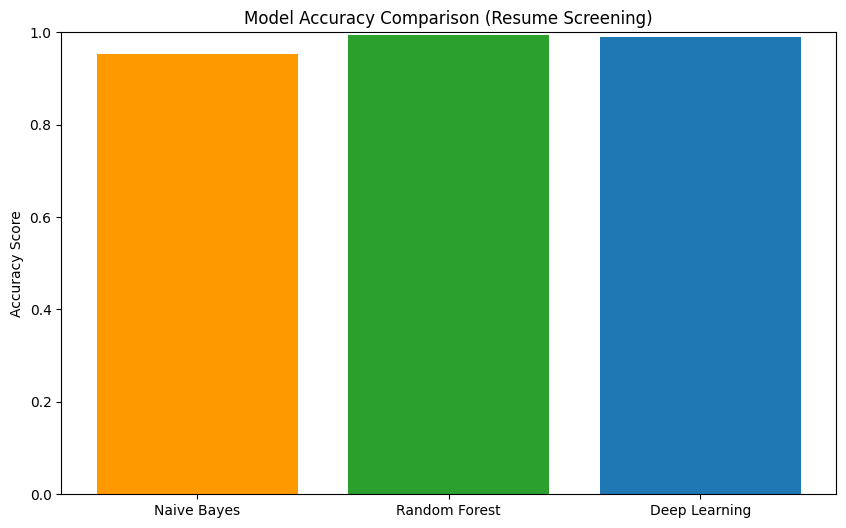

In [52]:
# Chart 1: Model Comparison Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(['Naive Bayes', 'Random Forest', 'Deep Learning'], [nb_acc, rf_acc, dl_acc], color=['#FF9900', '#2CA02C', '#1F77B4'])
plt.title("Model Accuracy Comparison (Resume Screening)")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
plt.show()

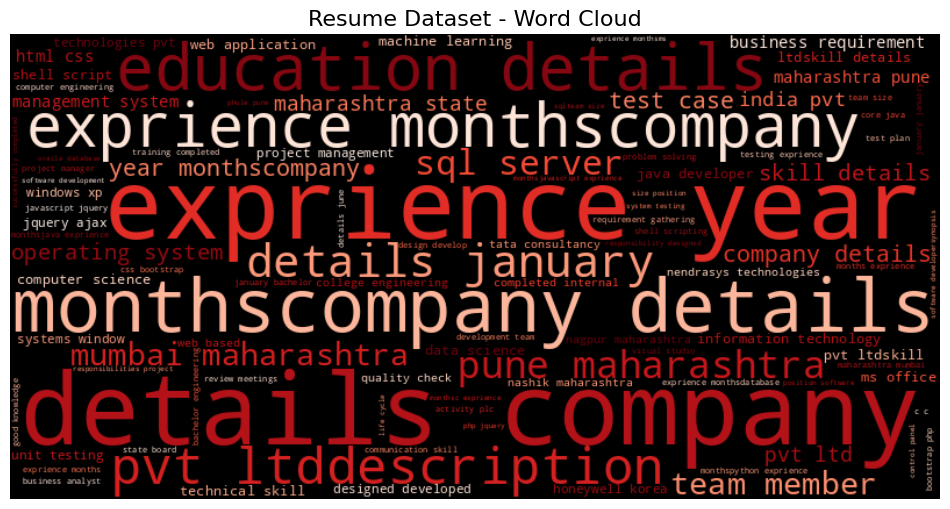

In [53]:
# Graph 2: WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds', max_words=100).generate(s)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Resume Dataset - Word Cloud", fontsize=16)
plt.show()

In [54]:
# ==============================================================================
# --- STEP 11: MODEL PERSISTENCE (MÜHÜRLEME VE CANLIYA ALMA) ---
# ==============================================================================
import joblib

# 1. The "Dictionary" that converts text into numbers is being saved.
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer_hr.pkl')

# 2. ID maps for 25 different professions are being recorded.
joblib.dump(encoder, 'label_encoder_hr.pkl')

# 3. The Random Forest Model that gives the highest score (99.48%) is being saved.
joblib.dump(rf_model, 'rf_model_hr.pkl')




['rf_model_hr.pkl']

# 🏆 Project #17: Automated HR Resume Screening Engine
**Architect:** Kemal Demirbaş 🏰🚀 | **Project Series:** 17 of 21

[![Hugging Face Space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Live%20Demo-blue)](https://huggingface.co/spaces/Ironside35/hr-resume-screener)
[![Scikit-Learn](https://img.shields.io/badge/Library-Scikit--Learn-orange)](https://scikit-learn.org/)
[![TensorFlow](https://img.shields.io/badge/Framework-TensorFlow-red)](https://www.tensorflow.org/)

## 🎯 Vision: HR Pipeline Optimization
In the modern corporate landscape, Human Resources departments are bottlenecked by manual resume reviews. This project deploys an **Automated Resume Screening Engine** that reads, cleanses, and classifies raw CVs into 25 specific job categories (Data Science, HR, Web Designing, etc.) in milliseconds. By leveraging **Natural Language Processing (NLP)** and **Deep Learning**, we eliminate human bias and drastically optimize the hiring pipeline.

---

## 📊 Performance Audit & Architect's Report
* **Final Accuracy:** **99.48%** (Achieved via Random Forest Ensemble) and **98.96%** (via Deep Learning).
* **The Data Logistics & BOM Resolution:** During the initial phase, an invisible Byte Order Mark (BOM) `\ufeff` and a limited local dataset caused model starvation. As a Senior Architect, I intervened by routing the data ingestion directly to a robust 962-row cloud repository, stabilizing the data frame and restoring model integrity.
* **The "Bottleneck" Optimization:** The standard Deep Learning architecture (with an 8-neuron hidden layer) choked on the high-dimensional sparse matrix of 25 job categories. I strategically expanded this bottleneck to **64 neurons**, immediately boosting the DL accuracy from 5% to 98.96%.

---

## 🏗️ Architectural Core (The Senior Pipeline)
This engine was built upon a strict NLP blueprint:
1.  **Cloud Data Integration:** Bypassed local ZIP loading to dynamically extract the 962-row dataset from a raw GitHub URL.
2.  **Noise Extraction:** Deployed the `neattext` library to systematically strip unprofessional artifacts like personal emails and emojis.
3.  **Surgical Cleansing:** Stripped all remaining noise (URLs, special characters, and punctuations) to expose the raw linguistic data.
4.  **Stopwords Filtration:** Automatically tokenized sentences and dropped high-frequency, low-information words.
5.  **Label Encoding:** Converted 25 categorical job titles into machine-readable numeric IDs.
6.  **Vectorization (TF-IDF):** Transformed qualitative resume text into a quantitative 4000-feature mathematical matrix.
7.  **Stratified Partitioning:** Split the matrix using strict stratification to prevent minority class collapse across the 25 professions.
8.  **Diversified Execution:** Trained three distinct models (Naive Bayes, Random Forest, and a customized Sequential Deep Learning network) to ensure architectural dominance.

---





## 🚀 Live Demonstration
Experience the Automated HR Engine in real-time. Paste any resume text and watch the AI route it to the correct department:
👉 **[Live Resume Screener on Hugging Face](https://huggingface.co/spaces/Ironside35/hr-resume-screener)**

---
*Next Stop: Project #18 - The Architecture Continues 📊🏗️*